# Error Analysis with pyannote.metrics

This is a tutorial on how to use pyannote.metrics to assess a speaker diarization system's robustness to either categorical features (like gender or accent) and time-series features (like SNR or reverb).

# Data Preparation
The error analysis tools run on lists of dictionaries, where each item represents an audio file, with respective keys for annotations and other information regarding that particular audio file. You will need:
- Prediction and ground-truth annotations (in rttm format).
- For categorical error analysis, you will need either:
    - rttms, where speaker labels are replaced with your labels of interest (the tool will handle mapping speakers and labels for you).
    - a dictionary mapping exact reference speaker labels to your labels of interest (e.g. {"SPK_001": "Female", "SPK_002": "Male"})
- For the temporal error analysis, you will need frame-based numpy arrays for your feature of interest and duration of audio as floats. Similarly, the tool will handle the resolution for you.
- You do not need the original audio

For this tutorial, we have some prepared files with ground-truth annotations on the benchmark dataset [DIHARD-III](https://dihardchallenge.github.io/dihard3/), predictions from pyannote's [precision-2](https://huggingface.co/pyannote/speaker-diarization-precision-2) model, outputs from a [gender classifier (VTC-2)](https://github.com/LAAC-LSCP/VTC), and outputs from pyannote's SNR and reverb estimator [brouhaha](https://huggingface.co/pyannote/brouhaha).

In [ ]:
# import pickle

# with open("data/files.pkl", "rb") as f:
#     files = pickle.load(f)

Below are some functions that may be handy for integrating your own rttm files (used for category_metrics), directories of npy arrays (used for temporal_metrics), and pyannote databases (which can contain audio durations and ground-truth annotations).

In [ ]:
# import numpy as np
# from pyannote.core import Annotation, Segment
# from pyannote.database import registry


# DATABASE_PATH = ... # yml
# PROTOCOL_PATH = "DIHARD.SpeakerDiarization.Benchmark" # for reference annotations

# MODEL_PREDICTION_FILE = ... # rttm

# CATEGORY_PREDICTIONS = ... # rttm
# TIME_SERIES_PREDICTIONS = ... # npy


# # --- RTTM loading -------------------------------------------------------------

# def load_rttm(rttm_path):
#     """Parse a single RTTM file into {uri: Annotation}."""
#     annotations = {}
#     with open(rttm_path) as f:
#         for line in f:
#             parts = line.strip().split()
#             if not parts or parts[0] != "SPEAKER":
#                 continue
#             uri      = parts[1]
#             onset    = float(parts[3])
#             duration = float(parts[4])
#             speaker  = parts[7]
#             if uri not in annotations:
#                 annotations[uri] = Annotation(uri=uri)
#             annotations[uri][Segment(onset, onset + duration)] = speaker
#     return annotations


# def make_rttm_loader(uri_to_annotation):
#     """Preprocessor factory: looks up file['uri'] in a {uri: Annotation} dict."""
#     def load_data(file):
#         return uri_to_annotation.get(file["uri"])  # None if missing
#     return load_data


# def make_npy_loader(path_template):
#     """Preprocessor factory: loads a whole .npy file per uri."""
#     def load_data(file):
#         return np.load(path_template.format(uri=file["uri"]))
#     return load_data


# # --- Load everything -----------------------------------------------------------

# precision_pred = load_rttm(PRECISION_PREDICTION_FILE)
# category_pred = load_rttm(CATEGORY_PREDICTIONS)

# # --- Build preprocessors ---------------------------------------------------

# preprocessors = {
#     "model": make_rttm_loader(model_pred),
#     "category": make_rttm_loader(category_pred), 
#     "snr":       make_npy_loader(TIME_SERIES_PREDICTIONS),
# }

# registry.load_database(DATABASE_PATH)
# protocol = registry.get_protocol(PROTOCOL_PATH, preprocessors=preprocessors)
# files = list(protocol.test())

# CategoryStats, CategoryErrorAnalysis

Category-level information regards speaker-stable characteristics such as their age, gender, and accent. If you use a segmentation classifier on audio that gives you a prediction for every speech turn segment, you can use CategoryStats to aggregate these information and map these predictions onto speaker labels. Alternatively, if you already have a mapping of speakers to categories (either precomputed or manually created), you can use that instead, but make sure the speaker labels match those in the reference!

From there, you can see the distribution of your audio according to these categories before you dive into any error analysis.

In [ ]:
# from pyannote.metrics.errors.category_metrics import CategoryStats, CategoryErrorAnalysis

### CategoryStats
This gives you insight into your data according to your reference annotations and category labels. It is independent of any hypothesis

In [ ]:
# stats = CategoryStats(files=files, speaker_annotation="annotation", category_annotation="gender",
#                       merge_labels={"child": ("OCH", "KCHI"), "male": ("MAL",), "female": ("FEM",)})

# stats.compute_durations(overlap=True)      # populates stats.durations, stats.durations_overlap

NameError: name 'CategoryStats' is not defined

Alternatively, you can try initializing with a pre-computed map. Just make sure to have at least one or the other.
If both are present, the pre-computed map will be used and the annotation will be ignored.

In [ ]:
# gender_map

In [ ]:

# stats = CategoryStats(files=files, speaker_annotation="annotation", speaker_category_map_key="gender_map",
#                       merge_labels={"child": ("OCH", "KCHI"), "male": ("MAL",), "female": ("FEM",)})

In [ ]:
# stats.durations                          # {'male': 120.3, 'female': 98.7, 'TOTAL': 219.0}
# stats.label_duration("female")              # 98.7
# stats.label_percentage("female")            # 0.45
# stats.label_ratio("male", "female")          # 1.22
# stats.print_summary()

# stats.compute_durations(overlap=False, uris=["DH_EVAL_0001"])   # recompute for a subset

# stats.get_missing_speaker_labels(verbose=True)   # diagnostic: speakers with no category mapping
# stats.get_category_classifier_accuracy()         # prints MD/FA of the category labels themselves

male: 53575.07s (51.6% of total)
female: 47515.17s (45.8% of total)
child: 2667.11s (2.6% of total)
TOTAL: 103757.36s


/opt/homebrew/Caskroom/miniconda/base/envs/pyannote/lib/python3.13/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


Missed Detections: 0.0020
False Alarms:      0.0000


### CategoryErrorAnalysis

CategoryErrorAnalysis provides a hypothesis-vs-reference error breakdown per category. It includes an internal instance of CategoryStats by default in order to normalize results. This means if you want to jump straight into analysis, you can just call CategoryErrorAnalysis.

Labels are discovered automatically, but if you want to rename or merge labels, you can use the merge_labels parameter.
You can then gather metrics for the entire dataset, subsets, within regions of overlapping speech only. You can also get confusion-only metrics, which will tell you how often confusion errors are committed within the same or different categories (e.g. male voices confused for male voices, or for female voices)

In [ ]:
# analysis = CategoryErrorAnalysis(files=files, speaker_annotation="annotation",
#                                   hypothesis_annotation="precision", category_annotation="gender",
#                                   merge_labels={"child": ("OCH", "KCHI"), "male": ("MAL",), "female": ("FEM",)})

# analysis.compute_distributions(normalized=True)   # populates the four error category attributes
# analysis.error_distribution         # {'md': {...}, 'fa': {...}, 'confusion': {...}, 'correct': {...}}
# analysis.confusion_durations        # {'male+female': 0.03, 'female+male': 0.02, ...}
# analysis.overlap_error_distribution # {'md': {...}, 'fa': {...}, 'confusion': {...}, 'correct': {...}}
# analysis.overlap_confusion_durations # {'male+female': 0.01, 'female+male': 0.01, ...}

/Users/audri/Documents/projects/pyannote-performance/data-scripts/error-analysis/temp_cat.py:745: UserWarning: [error_category_durations] Some speakers were skipped during 'confusion' duration counting.
hypothesis speakers with no mapping: ['1']
  durations = self.error_category_durations(subset, cat_map, error_type, verbose)
/Users/audri/Documents/projects/pyannote-performance/data-scripts/error-analysis/temp_cat.py:745: UserWarning: [error_category_durations] Some speakers were skipped during 'false alarm' duration counting.
hypothesis speakers with no mapping: ['1']
  durations = self.error_category_durations(subset, cat_map, error_type, verbose)
/Users/audri/Documents/projects/pyannote-performance/data-scripts/error-analysis/temp_cat.py:745: UserWarning: [error_category_durations] Some speakers were skipped during 'confusion' duration counting.
hypothesis speakers with no mapping: ['2']
  durations = self.error_category_durations(subset, cat_map, error_type, verbose)
/Users/audri/D

{'male+male': 0.008464309393507745,
 'female+female': 0.008550868402586412,
 'male+UNKNOWN': 0.002347789581904215,
 'male+female': 0.0014368249003110273,
 'female+male': 0.002422215690507573,
 'female+child': 0.00035818031519783456,
 'child+child': 0.0022949951782979495,
 'child+female': 0.0006332701937829282,
 'male+child': 9.426025288485916e-06,
 'female+UNKNOWN': 0.0013444757668360648,
 'child+UNKNOWN': 9.860868026342911e-05,
 'child+male': 0.00017247145597403546}

You can also compare two different model hypotheses by using set_hypothesis:

In [ ]:
# analysis.set_hypothesis("community")
# analysis.compute_distributions(normalized=True)
# community_dist = analysis.error_distribution

# analysis.set_hypothesis("precision")
# analysis.compute_distributions(normalized=True)
# precision_dist = analysis.error_distribution

# CategoryErrorAnalysis.diff_error_rates(community_dist, precision_dist)   # prints + returns the deltas

/Users/audri/Documents/projects/pyannote-performance/data-scripts/error-analysis/temp_cat.py:745: UserWarning: [error_category_durations] Some speakers were skipped during 'confusion' duration counting.
hypothesis speakers with no mapping: ['0', '1', '7']
  durations = self.error_category_durations(subset, cat_map, error_type, verbose)
/Users/audri/Documents/projects/pyannote-performance/data-scripts/error-analysis/temp_cat.py:745: UserWarning: [error_category_durations] Some speakers were skipped during 'false alarm' duration counting.
hypothesis speakers with no mapping: ['0', '1', '7']
  durations = self.error_category_durations(subset, cat_map, error_type, verbose)
/Users/audri/Documents/projects/pyannote-performance/data-scripts/error-analysis/temp_cat.py:745: UserWarning: [error_category_durations] Some speakers were skipped during 'confusion' duration counting.
hypothesis speakers with no mapping: ['6']
  durations = self.error_category_durations(subset, cat_map, error_type, ver

Improvements from b to a
Change in proportion of each category's speech affected by each error type:

Missed Detections
  * male: +0.9%
  * female: +2.4%
  * child: +2.4%
False Alarms
  * male: +2.1%
  * female: +0.9%
  * child: +0.6%
Correct
  * male: -3.4%
  * female: -4.8%
  * child: -9.7%
Confusion (Reference speakers)
  * male: +2.5%
  * female: +2.4%
  * child: +7.3%
Confusion (Predicted speakers)
  * male: +2.7%
  * female: +2.6%
  * child: +7.1%


{'md': {'male': 0.009177789512609058,
  'female': 0.02354146908943218,
  'child': 0.02403427232793018},
 'fa': {'male': 0.02105243485549104,
  'female': 0.008576439181302305,
  'child': 0.006402065458166295},
 'correct': {'male': -0.033718224699597954,
  'female': -0.04761832504285868,
  'child': -0.09741187833413623},
 'confusion': {'ref': {'male': 0.024540435186988452,
   'female': 0.02407685595342629,
   'child': 0.07337760600620585},
  'pred': {'male': 0.02682336251566989,
   'female': 0.02579110833099309,
   'child': 0.07080365699476752}}}

Or if you just want statistics for a certain subset of files or certain kind of error, you can do that too. This extracts the metrics as plain dicts, which are the objects used for plotting in the next step.

In [ ]:
# md_subset = analysis.subset_by_error_type(analysis._get_or_compute_diff("DH_EVAL_0001"), "missed detection")
# durations_by_category = analysis.error_category_durations(
#     md_subset, analysis.category_stats.speaker_category_map["DH_EVAL_0001"], "missed detection")

# Plotting CategoryErrorAnalysis

Now the fun part: visualizations!

After creating an instance of CategoryStats or CategoryErrorAnalysis, just make sure to call compute_durations or compute_distributions respectively, then you're ready to plot!

In [ ]:
# from pyannote.metrics.errors import category_plots as tcp

Here we plot percentages and durations of every category's speech in the data using CategoryStats, no hypothesis needed.

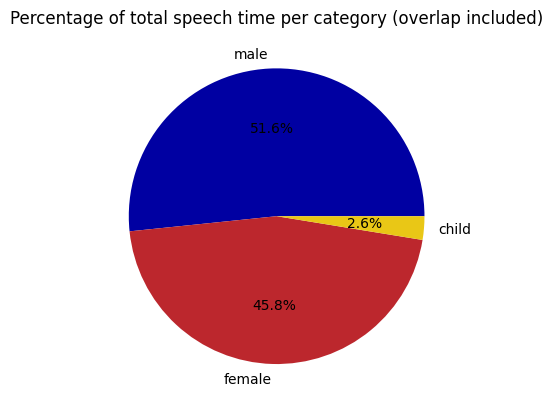

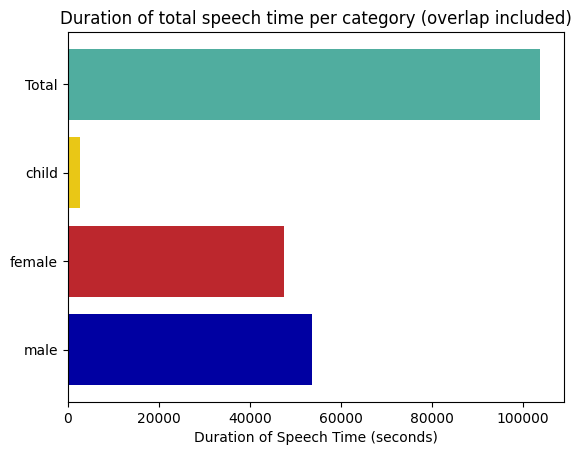

In [ ]:
# stats = CategoryStats(files=files, speaker_annotation="annotation", category_annotation="gender",
#                       merge_labels={"child": ("OCH", "KCHI"), "male": ("MAL",), "female": ("FEM",)})
# stats.compute_durations(overlap=True)

# tcp.plot_percentages(stats)   # pie chart of speech % per category label
# tcp.plot_durations(stats)     # horizontal bar chart of speech duration per category label

This plots a heatmap of which categories get confused with which

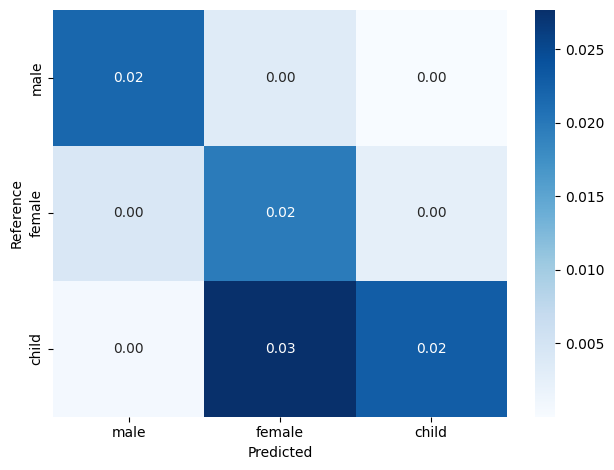

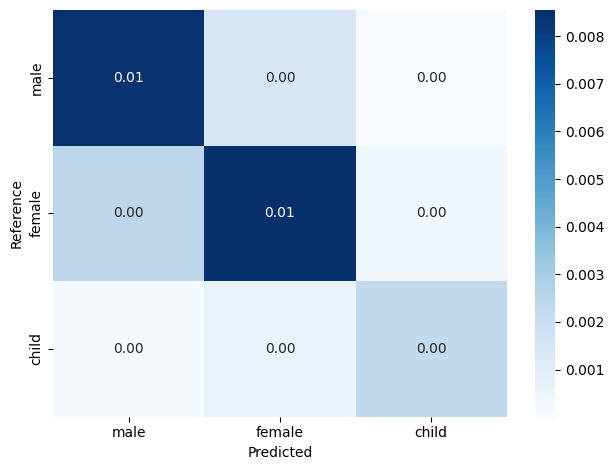

In [ ]:
# analysis = CategoryErrorAnalysis(files=files, speaker_annotation="annotation",
#                                   hypothesis_annotation="precision", category_annotation="gender",
#                                   merge_labels={"child": ("OCH", "KCHI"), "male": ("MAL",), "female": ("FEM",)})
# analysis.compute_distributions(normalized=True)

# tcp.plot_confusion(analysis)                       # all-speech confusion matrix
# tcp.plot_confusion(analysis, for_overlap=True)      # confusion restricted to overlap regions

Since the analysis metrics have already been computed, you can customize the plot quickly and as many times as you need without having to wait for recalculation each time. Below, I've even customized the bar chart colors to be extra garish -- that freedom is yours too!

- show_confusion_split shows distribution of inter/intra confusion errors
- show_overlap shows % of errors occurring in regions of overlapping speech

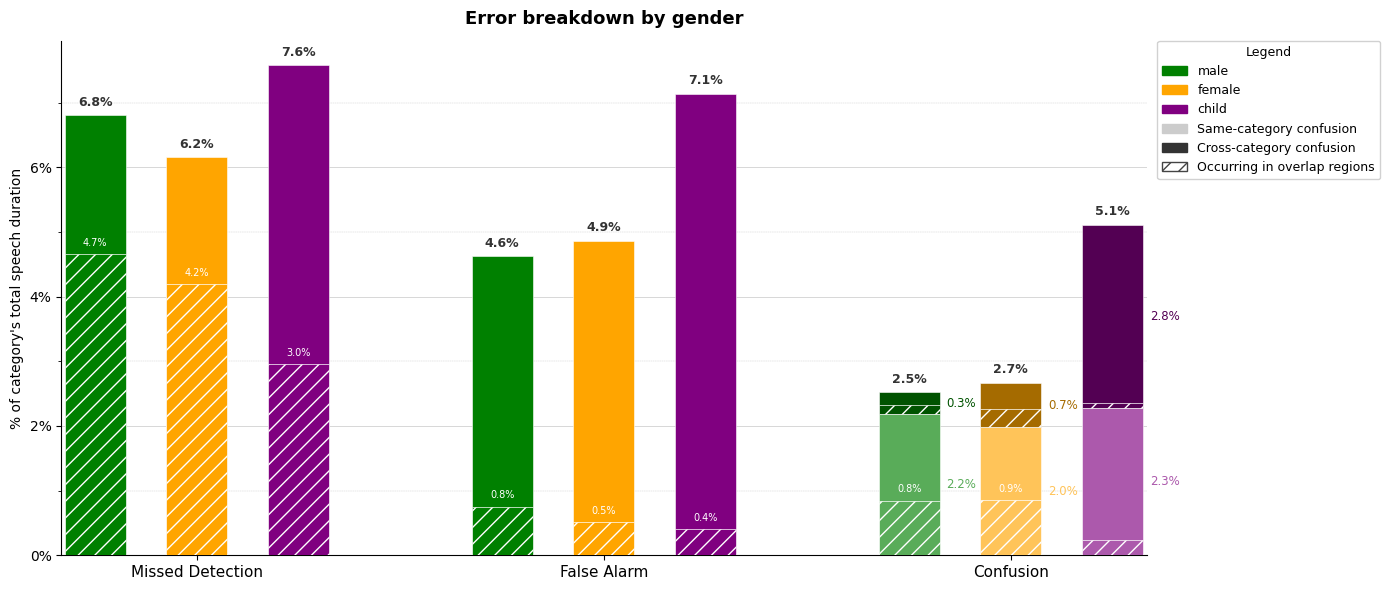

In [ ]:
# tcp.plot_analysis(analysis, show_confusion_split=True, show_overlap=True,
#               title="Error breakdown by gender",
#               colors={"male": "#008000", "female": "#FFA500", "child": "#800080"})

# TemporalErrorAnalysis
This tool analyzes diarization errors according to time-series data represented as an npy array. There is currently support for 1D data such as SNR values taken every 40ms, and 2D data such as confidence scores with a dimension of (speaker turns, speaker count).

The time-series data is then split into bands, such as intervals of 10dB, and you will see the performance on audio within those particular bands.

You can use one or more signal_transforms to shape your time-series data, and you can also compare multiple signals or multiple plots at a time. Just make sure to have the duration of the audio, so the tool can accordingly determine the resolution of your time-series data.

In [ ]:
# from pyannote.metrics.errors.temporal_metrics import TemporalErrorAnalysis

Here is how to compute and read the metrics dict directly.
Note:
- bin_ranges = (-20,80,10) will produce bins from -20 to 80 by steps of 10
- bin_ranges = None will auto-pick nice bin edges from the signal

In [ ]:
# analysis = TemporalErrorAnalysis(
#     files=files,
#     reference="annotation",
#     hypothesis="precision",
#     durations="duration",
#     signal="music",
#     overlay_signal=None,
#     signal_transforms={"music": ["squeeze", "scale_percentage_up"]},
# )

# analysis.compute_metrics(bin_ranges=(-20,80,10))   

# analysis.metrics       # {"lo_hi": {"correct": {...}, "confusion": {...}, ...}, ...}
# analysis.bin_ranges     # [(lo, hi), (lo, hi), ...] -- same bins as analysis.metrics.keys()

Processing files:   0%|          | 0/259 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/pyannote/lib/python3.13/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(
Processing files: 100%|██████████| 259/259 [00:11<00:00, 21.76it/s]


[(-20.0, -10.0),
 (-10.0, 0.0),
 (0.0, 10.0),
 (10.0, 20.0),
 (20.0, 30.0),
 (30.0, 40.0),
 (40.0, 50.0),
 (50.0, 60.0),
 (60.0, 70.0),
 (70.0, 80.0)]

Bin ranges can be automatically computed for you, based on the distibution of the data. The example below shows how to review these ranges, and you can also specify the (min, max, interval) range for yourself, which can be helpful if you're comparing across models.

In [ ]:
# preview_bins = analysis.compute_bin_ranges()   # peeks at the signal range, no error accumulation yet
# print(preview_bins)                            # inspect before deciding on a fixed (min, max, interval)

# SHARED_BINS = (-20, 80, 5)
# analysis.compute_metrics(bin_ranges=SHARED_BINS)   # now locked to bins every model can share

all_values range: 0.000000 – 99.881813
[(0.0, 10.0), (10.0, 20.0), (20.0, 30.0), (30.0, 40.0), (40.0, 50.0), (50.0, 60.0), (60.0, 70.0), (70.0, 80.0), (80.0, 90.0), (90.0, 100.0)]


Processing files: 100%|██████████| 259/259 [00:11<00:00, 21.69it/s]


Here's some more plain arrays you can extract:

In [ ]:
# correct_pct = analysis.extract_binned_signal(error_type="correct", metric="percentage")
# confusion_seconds = analysis.extract_binned_signal(error_type="confusion", metric="duration")

# Visualizing TemporalErrorAnalysis

Below are the plotting functions for visualizing the error analysis! This first function is helpful for sanity checking your time-series data.

In [ ]:
# from pyannote.metrics.errors import temporal_plots as ttp

This helper function is good for running a sanity-check on a raw signal

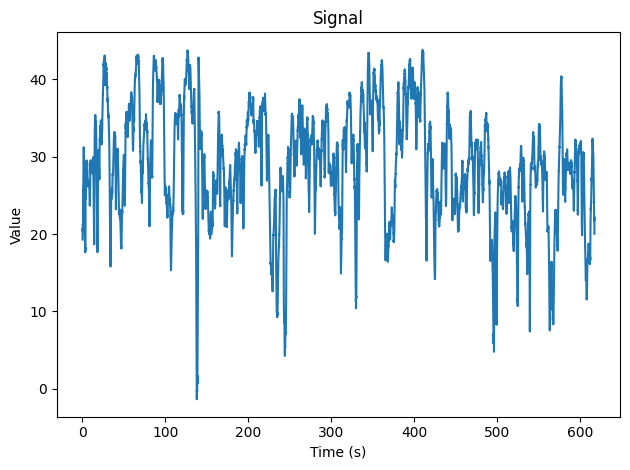

In [ ]:
# ttp.plot_signal(files[0]["snr"], files[0]["duration"])

The plot below shows how to visualize all the computed metrics. Below, you can see a pattern of performance degradation in lower-SNR areas (right plot), and you can also see there is not a lot of audio with an SNR of less than -10dB (left plot).

Processing files:   0%|          | 0/259 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/pyannote/lib/python3.13/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(
Processing files: 100%|██████████| 259/259 [00:11<00:00, 22.02it/s]


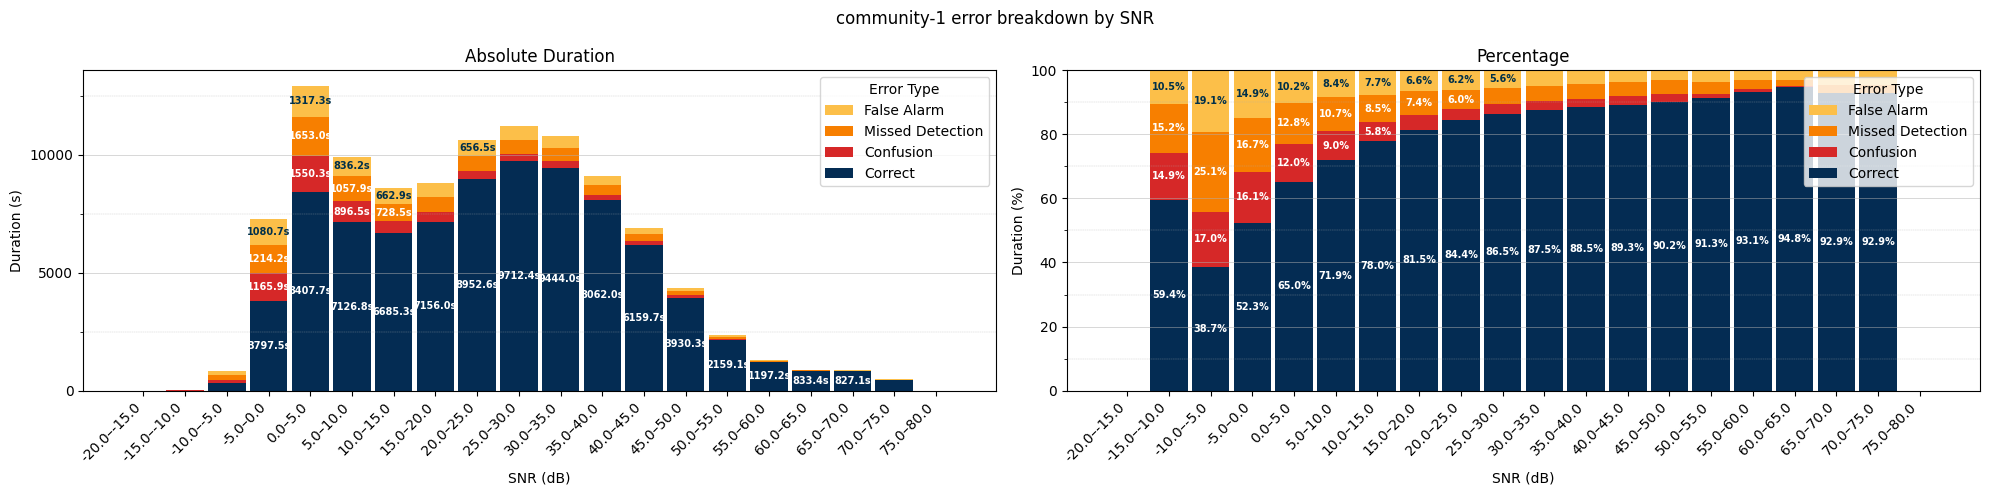

In [ ]:
# model_a = TemporalErrorAnalysis(files=files, reference="annotation",
#                                      hypothesis="community", durations="duration", signal="snr")
# model_a.compute_metrics(bin_ranges=SHARED_BINS)   # bin_ranges=None will auto-pick nice bin edges

# ttp.plot(model_a, view="full", show_values=True, show_overlay=False,
#      x_label="SNR (dB)", title="community-1 error breakdown by SNR")

To compare two models directly, you can use plot_comparison. The example below shows that pyannote's precision-2 performs much better than community-1 across nearly every SNR band, but still has degraded performance with lower SNR audio.

Processing files:   0%|          | 0/259 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/pyannote/lib/python3.13/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(
Processing files: 100%|██████████| 259/259 [00:12<00:00, 20.65it/s]


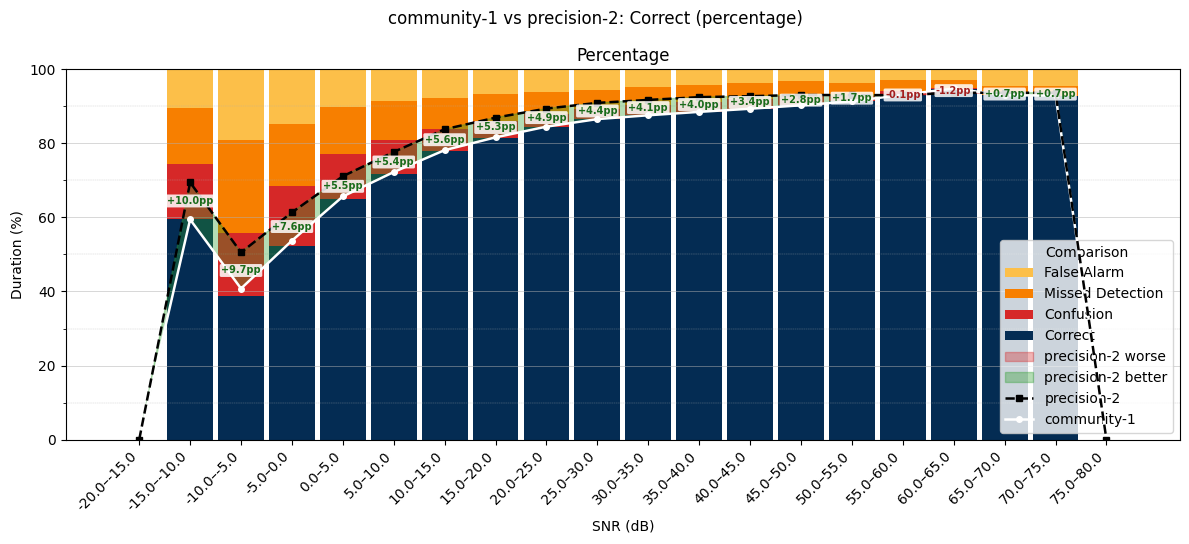

In [ ]:
# model_b = TemporalErrorAnalysis(files=files, reference="annotation",
#                                   hypothesis="precision", durations="duration", signal="snr")
# model_b.compute_metrics(bin_ranges=SHARED_BINS)   # reuse model_a's bins so they line up

# ttp.plot_comparison(model_a, model_b, error_type="correct", metric="percentage",
#                  model_label="community-1", other_label="precision-2", x_label="SNR (dB)",
#                  percentage_pos="lower right")


If you're comparing more than two models, plot_comparison_multi will be more useful, as you'll be able to look at a delta plot and a view that's designed to accommodate many models that may have very close performance.

Processing files:   0%|          | 0/259 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/pyannote/lib/python3.13/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(
Processing files: 100%|██████████| 259/259 [00:12<00:00, 20.56it/s]


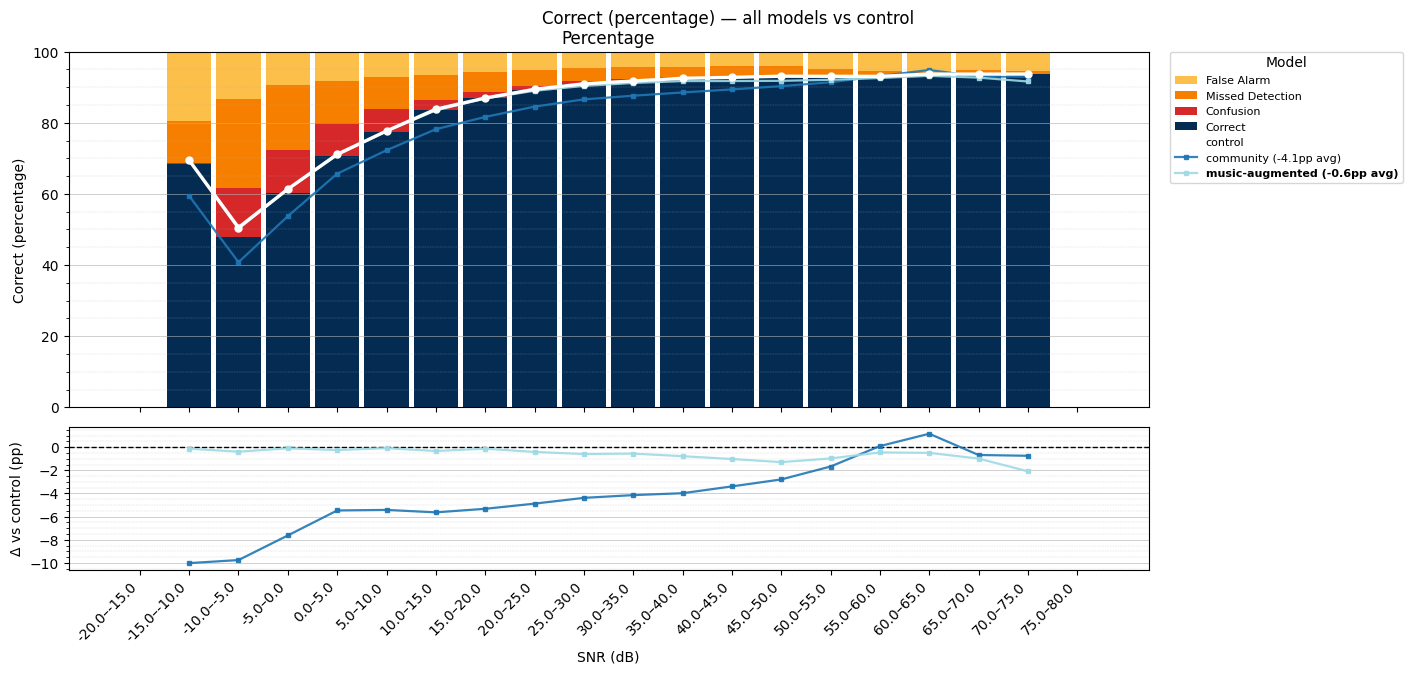

In [ ]:
# SHARED_BINS = (-20, 80, 5)   # (min, max, interval) -- pick once, reuse everywhere
# MODEL_KEYS = ["community", "music-augmented",]

# # model a serves as the baseline
# model_a = TemporalErrorAnalysis(files=files, reference="annotation",
#                                      hypothesis="precision", durations="duration", signal="snr")
# model_a.compute_metrics(bin_ranges=SHARED_BINS)

# others = {}
# for key in MODEL_KEYS:
#     temp = TemporalErrorAnalysis(files=files, reference="annotation",
#                                  hypothesis=key, durations="duration", signal="snr")
#     temp.compute_metrics(bin_ranges=SHARED_BINS)
#     others[key] = temp

# ttp.plot_comparison_multi(model_a, others, error_type="correct", metric="percentage",
#                        baseline_label="control", x_label="SNR (dB)")
